# Genre Operational Synergy

The investment firm wants to identify which game genres have the strongest operational synergy based on publisher portfolios.

## Load and prepare the data

Load the Steam dataset and prepare the publisher and genre information needed to represent publisher portfolios.

In [1]:
import numpy as np
import pandas as pd


STEAM_PATH = "../../data/steam/steam.csv"

GENRES = [
    "Action",
    "Adventure",
    "Casual",
    "Indie",
    "RPG",
    "Strategy",
    "Simulation",
    "Sports",
]

steam = pd.read_csv(STEAM_PATH)

print(
    "Dataset loaded:",
    f"{len(steam):,} games",
)

steam.head()

Dataset loaded: 27,075 games


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


## Prepare publisher–genre assignments

Expand games with multiple genre or publisher labels so each publisher's activity can be summarized separately within each genre.

In [2]:
data = (
    steam.assign(
        genre=steam["genres"]
        .fillna("")
        .str.split(";"),
        publisher_name=steam["publisher"]
        .fillna("")
        .str.split(";"),
    )
    .explode("genre")
    .explode("publisher_name")
)

data["genre"] = (
    data["genre"]
    .str.strip()
)

data["publisher_name"] = (
    data["publisher_name"]
    .str.strip()
)

data = data[
    data["genre"].isin(GENRES)
    & data["publisher_name"].ne("")
].drop_duplicates(
    [
        "appid",
        "publisher_name",
        "genre",
    ]
)


print(
    "Games represented:",
    f"{data['appid'].nunique():,}",
)

print(
    "Publishers represented:",
    f"{data['publisher_name'].nunique():,}",
)

print(
    "Publisher–genre assignments:",
    f"{len(data):,}",
)

Games represented: 26,708
Publishers represented: 14,044
Publisher–genre assignments: 69,611


## Represent publisher portfolios

Use publisher title counts to represent operational activity within each genre.

Genres with similar publisher title-count distributions are treated as having stronger operational synergy.

In [3]:
title_matrix = (
    data
    .groupby(
        [
            "publisher_name",
            "genre",
        ]
    )["appid"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(
        columns=GENRES,
        fill_value=0,
    )
)


print(
    "Publisher portfolios:",
    f"{len(title_matrix):,} publishers × "
    f"{len(title_matrix.columns)} genres",
)

print(
    "Portfolio measure:",
    "publisher title counts",
)

Publisher portfolios: 14,044 publishers × 8 genres
Portfolio measure: publisher title counts


## Calculate genre synergy

Calculate cosine similarity between publisher title-count portfolios and identify the genre pair with the highest similarity.

In [4]:
x = title_matrix.to_numpy()

similarity = (
    x.T @ x
) / np.outer(
    np.linalg.norm(x, axis=0),
    np.linalg.norm(x, axis=0),
)

np.fill_diagonal(
    similarity,
    np.nan,
)


i, j = np.unravel_index(
    np.nanargmax(similarity),
    similarity.shape,
)

genre_1 = GENRES[i]
genre_2 = GENRES[j]
score = similarity[i, j]


print(
    "Strongest genre pair:",
    f"{genre_1} + {genre_2}",
)

print(
    "Synergy score:",
    f"{score:.3f}",
)

Strongest genre pair: Adventure + Casual
Synergy score: 0.724


## Visualize the result

Visualize the strongest genre pair and its similarity score.

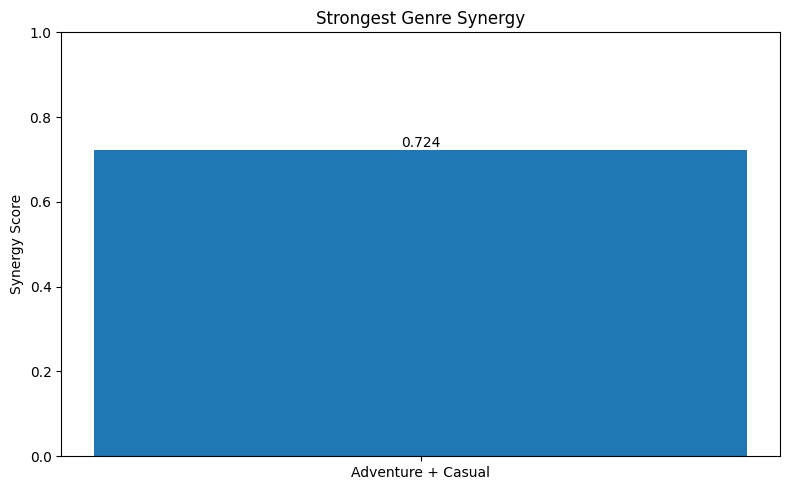

In [5]:
import matplotlib.pyplot as plt


label = f"{genre_1} + {genre_2}"

fig, ax = plt.subplots(
    figsize=(8, 5)
)

bar = ax.bar(
    [label],
    [score],
)

ax.set_title(
    "Strongest Genre Synergy"
)

ax.set_ylabel(
    "Synergy Score"
)

ax.set_ylim(0, 1)

ax.text(
    bar[0].get_x() + bar[0].get_width() / 2,
    score,
    f"{score:.3f}",
    ha="center",
    va="bottom",
)

plt.tight_layout()
plt.show()

## Conclusion

**Adventure** and **Casual** exhibit the strongest operational synergy, with a cosine similarity score of approximately **0.724**.

This indicates that the two genres have the most similar publisher title-count portfolios among the genres analyzed.